# CAMM Hackathon 13: Two Previous Problems Revisited with Agents

In this notebook we revisit two problems from earlier CAMM hackathons and suggest solving them again, but this time with an **agentic approach**.

## What is an agent?

For this hackathon, an agent is an LLM-based system that can **plan**, **use tools**, **inspect intermediate results**, and **iterate** toward a goal instead of producing only one direct answer.

A simple agent loop is:

1. observe the current state
2. decide what to do next
3. call a tool or run code
4. evaluate the result
5. revise the plan if needed

## Good starting references

- Anthropic, [Building Effective Agents](https://www.anthropic.com/engineering/building-effective-agents)
- OpenAI, [A Practical Guide to Building AI Agents](https://openai.com/business/guides-and-resources/a-practical-guide-to-building-ai-agents/)


In [2]:
# !pip install gpytorch
# 

In [3]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line


## Problem 1: STEM Image Restoration

This problem comes from [**CAMM Hackathon #10**](https://github.com/kbarakati/camm_hackathon/blob/k4my4r/docs/day_10_27032026/CAMM_hackaton_10_Image_Restoration.ipynb).

**Task:** given a 2D microscopy intensity image and a binary loss mask, reconstruct the missing regions and estimate uncertainty.


In [4]:
image_files = {
    "graphene_2.h5": "14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs",
    "HAADF_21.h5": "1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN",
}

for filename, file_id in image_files.items():
    if not Path(filename).exists():
        !gdown {file_id} -O "{filename}"
    else:
        print(f"Using existing file: {filename}")


Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /Users/utkarshpratiush/project/camm-hack-13th-mar-2026/fir-8th-may/graphene_2.h5
100%|██████████████████████████████████████| 17.1M/17.1M [00:02<00:00, 7.99MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /Users/utkarshpratiush/project/camm-hack-13th-mar-2026/fir-8th-may/HAADF_21.h5
100%|██████████████████████████████████████| 4.53M/4.53M [00:00<00:00, 4.54MB/s]


In [5]:
import json


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)


def _load_item(obj):
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}
        if all(k.isdigit() for k in keys):
            return [_load_item(obj[k]) for k in sorted(keys, key=lambda x: int(x))]
        out = {k: _load_item(obj[k]) for k in keys}
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None
        return out

    if isinstance(obj, h5py.Dataset):
        data = obj[()]
        if np.isscalar(data):
            return data
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except Exception:
                return data.decode()
        if getattr(data, "dtype", None) is not None and data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except Exception:
                return [x.decode() for x in data]
        return data

    raise ValueError(f"Unknown HDF5 object type: {type(obj)}")


def mask_below_line(im, frac=0.6, above=True):
    h, w = im.shape
    row = int(frac * h)
    mask = np.zeros((h, w), dtype=bool)
    mask[:row, :] = True if above else False
    mask[row:, :] = False if above else True
    return mask


def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=0):
    rng = np.random.default_rng(seed)
    h, w = im.shape
    mask = np.zeros((h, w), dtype=bool)
    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        ort = rng.choice(orientations) if orientation == "mixed" else orientation
        if ort == "horizontal":
            mask[rng.integers(0, h), :] = True
        elif ort == "vertical":
            mask[:, rng.integers(0, w)] = True
        else:
            r0, c0 = rng.integers(0, h), rng.integers(0, w)
            r1, c1 = rng.integers(0, h), rng.integers(0, w)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < h) & (cc >= 0) & (cc < w)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        mask = binary_dilation(mask, structure=np.ones((thickness, thickness), dtype=bool))
    return ~mask


In [6]:
data = load_hdf5_to_dict("graphene_2.h5")
data_more = load_hdf5_to_dict("HAADF_21.h5")

im0 = data["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"][:1000, :1000]
im1 = data["Measurement_001"]["Channel_000"]["HAADF"]["HAADF"][:1000, :1000]
im2 = data["Measurement_001"]["Channel_000"]["HAADF"]["HAADF"][:1000, -1000:]
im3 = data_more["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"]

ims = [im0, im1, im2, im3]


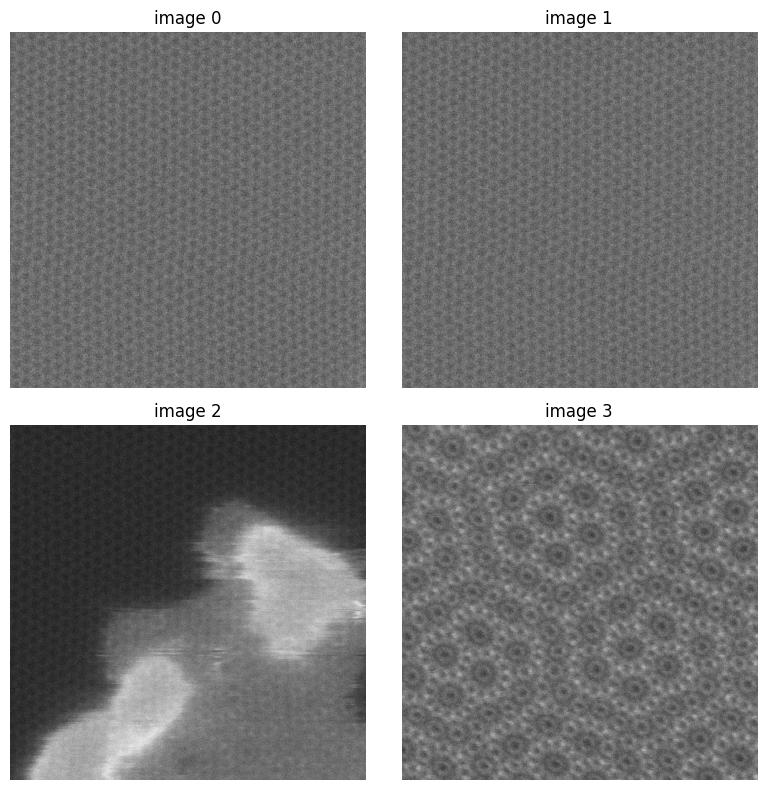

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(ims[i], cmap="gray")
    ax.set_title(f"image {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


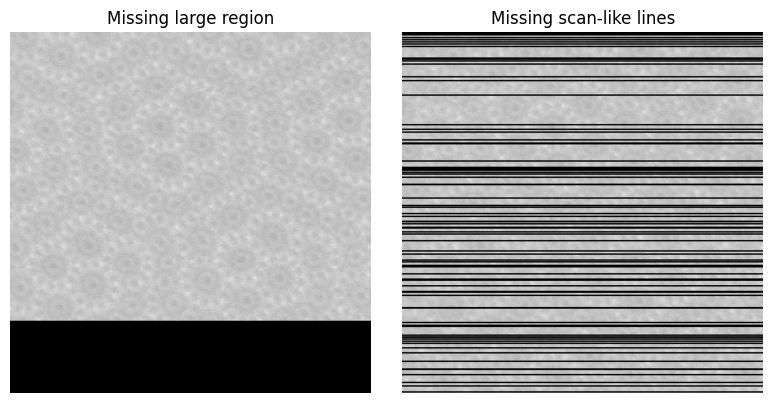

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(mask_below_line(im3, frac=0.8) * im3, cmap="gray")
ax[0].set_title("Missing large region")
ax[0].axis("off")

ax[1].imshow(mask_lines(im3, seed=0) * im3, cmap="gray")
ax[1].set_title("Missing scan-like lines")
ax[1].axis("off")
plt.tight_layout()

plt.show()


### Can we design an agent which will design and execute uncertanty aware image reconstruction framework?

## Problem 2: Active Experimental Design under Noise and Budget Constraints

This problem comes from [**CAMM Hackathon #11**](https://github.com/kbarakati/camm_hackathon/blob/k4my4r/docs/day_11_10042026/CAMM_Hackaton_11.ipynb).

**Task:** design a strategy that decides **where to measure**, **in what order**, and **for how long**, while accounting for measurement noise, limited budget, and movement cost.


### Minimal starter setup

The general setup cell above already installs the required packages. The cells below give a lightweight starting point for testing an adaptive measurement strategy.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch


In [9]:
# Example target functions for testing your strategy

def unimodal(x):
    return 1.2 * np.exp(-0.5 * ((x - 2.3) / 0.7) ** 2) + 0.1


def oscillatory(x):
    return 0.55 + 0.15 * np.sin(1.8 * x) + 0.08 * np.cos(6.0 * x)

def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res/40


def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 7)**2 + 0.45 * x

    return res/10

def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x - 2.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.08**2))
    )
    return res


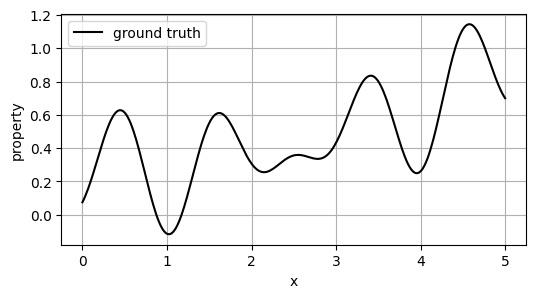

In [10]:
x_grid = np.linspace(0, 5, 300)
f_true = multimodal

plt.figure(figsize=(6, 3))
plt.plot(x_grid, f_true(x_grid), 'k', label='ground truth')
plt.xlabel('x')
plt.ylabel('property')
plt.grid()
plt.legend()
plt.show()


In [11]:

#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [12]:
# Simple budget accounting example
budget_total = 12.0
travel_weight = 0.15

# Example move from x=1.0 to x=3.5 with acquisition time 0.8
x_prev = 1.0
x_next = 3.5
acq_time = 0.8

travel_cost = travel_weight * abs(x_next - x_prev)
step_cost = acq_time + travel_cost
print('Example step cost:', round(step_cost, 3))
print('Remaining budget after step:', round(budget_total - step_cost, 3))


Example step cost: 1.175
Remaining budget after step: 10.825


In [13]:

#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

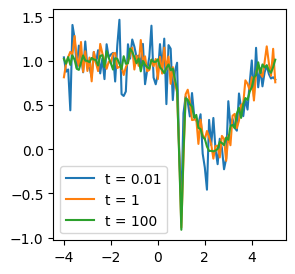

In [14]:

#@title example: grid measurements with different acqusition time

x = np.linspace(-4,5, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]


sim_decay = MeasurementSimulator(
    ground_truth_model=broad_narrow,
    noise_model=noise_decay_floor,
    rng=2,
)


fig, ax = plt.subplots(figsize=(3,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax.plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')

ax.legend()

#### Can an agentic approach be useful for integration such experimental campaigns?

## index 1
Q1. Questions to explore:


* What is the minimal architecture for an agentic system?
* How do I build a basic prototype with:

  * LLM (via OpenRouter),
  * tools,
  * memory,
  * reasoning/task loop?

How do I evaluate improvements?
Possible metrics:

* task success,
* tool usage quality,
* memory usefulness,
* recovery from failures,
* autonomy level,
* latency/cost.

What does “better agentic behavior” mean?

* memory,
* reflection/retry,
* re-planning,
* multi-step reasoning,
* improved tool selection.

Framework exploration:

* Is [smolagents](https://github.com/huggingface/smolagents?utm_source=chatgpt.com) best for transparent step-wise agents?
* Or should I explore LangGraph, AutoGen, or a custom lightweight framework?


## index 2
Great breakdown! Let me think through this systematically.Here's a structured map of everything you asked, and then a visual to tie it all together.

**What are you building?** An agentic framework that takes a damaged microscopy image + a mask, and autonomously decides *which* inpainting method to try, runs it, checks the quality, and iterates — rather than you hardcoding one pipeline.

---

**The simplest possible agent** is just: LLM → pick a tool → run it → look at the result → loop. For this problem, the tools would be things like `biharmonic_inpaint`, `gaussian_fill`, `gp_interpolate`, `compute_psnr`. You call the LLM with the image description and current metrics, it says "try GP next with RBF kernel", you run it, feed the metric back, repeat.

**Making it better** means adding:
- *Memory* — the agent remembers what it already tried (and what failed) across iterations, so it doesn't repeat bad choices
- *Reflection* — after each attempt it critiques its own output ("the edges are blurry, try a sharper prior")
- *Planning* — it lays out a strategy before diving in, rather than just reacting
- *Tools* — each method becomes a callable function with a schema the LLM understands
- *Metrics to evaluate quality* — PSNR, SSIM, and uncertainty calibration (does the uncertainty map actually correlate with error?) are the key ones here

**What "better" means concretely:** lower PSNR gap between restored and ground truth, well-calibrated uncertainty (high σ where the error is actually high), and visually coherent textures at atom scale.

---

**On the LLM / API question:** You can absolutely use OpenRouter — it gives you access to GPT-4o, Claude, Mistral etc. behind one endpoint. The key is that you're just hitting a REST API and injecting tool results back as messages. No framework required for a basic loop.
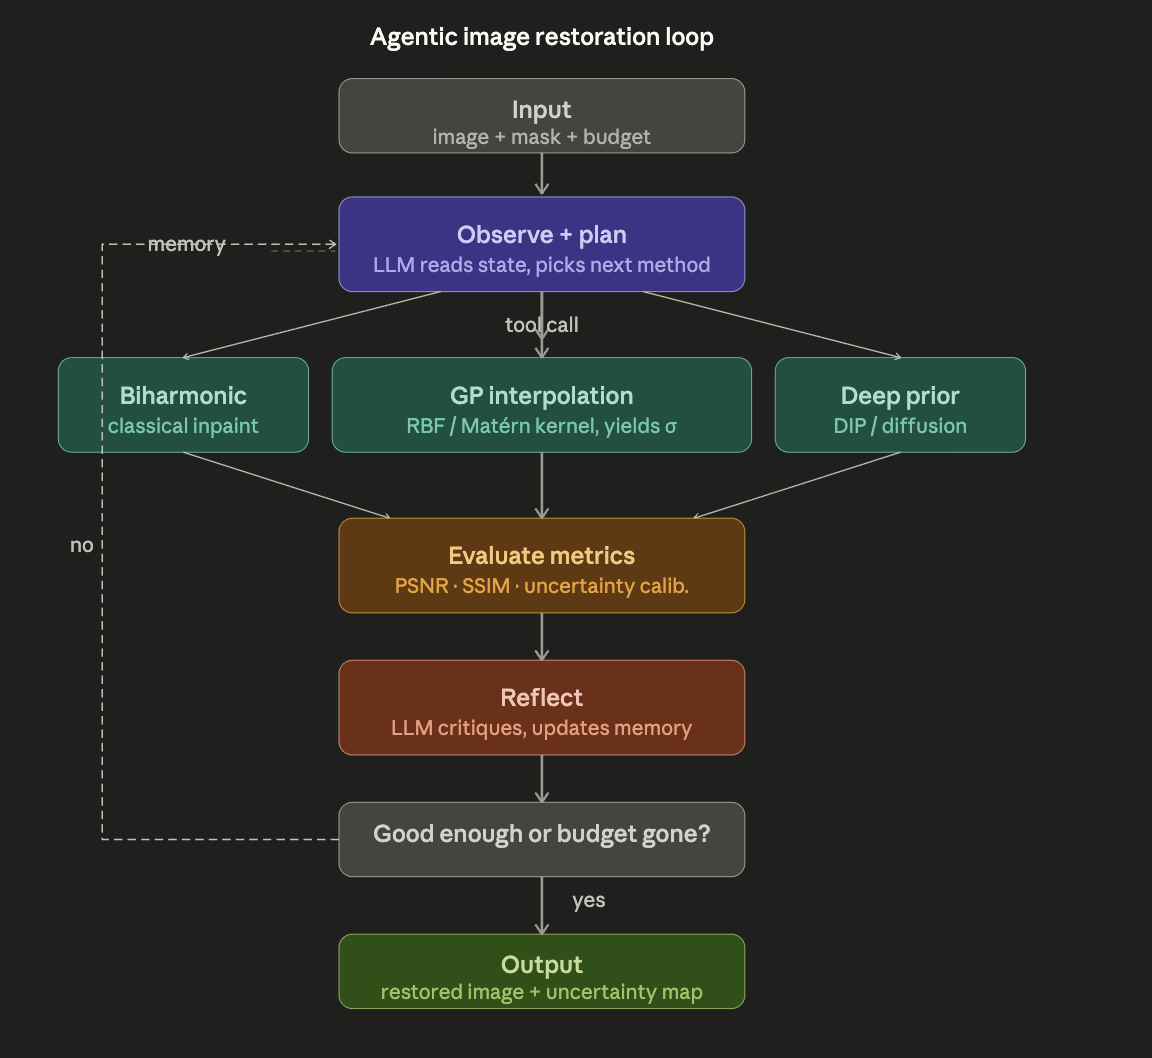
**smolagents vs. raw loop:** `smolagents` (HuggingFace) is good for *code-writing agents* — the LLM literally writes Python and runs it, which is useful here because you want it to experiment with kernel parameters, not just pick from a fixed menu. The tradeoff is it's harder to control and debug. A hand-rolled ReAct loop (reason → act → observe) is more transparent and easier to instrument when you're learning. Start with the raw loop, add smolagents later if you want the LLM to write novel code.---

**Recommended starting path:**

1. **Week 1 — raw ReAct loop.** Hard-code 3 tools (biharmonic, GP, a simple Gaussian fill). Use OpenRouter with Claude or GPT-4o. The LLM gets the current PSNR + SSIM as a string and picks the next tool. Log everything.

2. **Week 2 — add memory + reflection.** Pass the full history of "tried X, got PSNR=28, edges blurry" back into each prompt. Watch the agent avoid repeating bad choices.

3. **Week 3 — smolagents or proper tool schemas.** If you want the LLM to tune kernel parameters (not just pick a method name), smolagents' code-execution mode is the right upgrade — it can literally write `kernel = Matern(length_scale=0.3)` and run it.

4. **Evaluation harness.** The one non-negotiable: always keep a held-out ground truth patch so you can compute real PSNR. Uncertainty calibration = compare predicted σ to actual pixel error across the masked region.

What part do you want to dig into first — the tool definitions, the prompt design for the LLM, or the metrics/evaluation setup?

## Index 3 
USING Nanobanana/chatGPT/mulitmodal model directly to inpaint

Prompt - do inpainitng of these images :

context: they are microsocpy images - idea is that you loose information in scanning tue to hardware issue or you miss regions intentionaly to inpaint to save time - can we reconstruct it?

In [58]:
plt.imsave("Image0-GT.png", im0, cmap="gray")

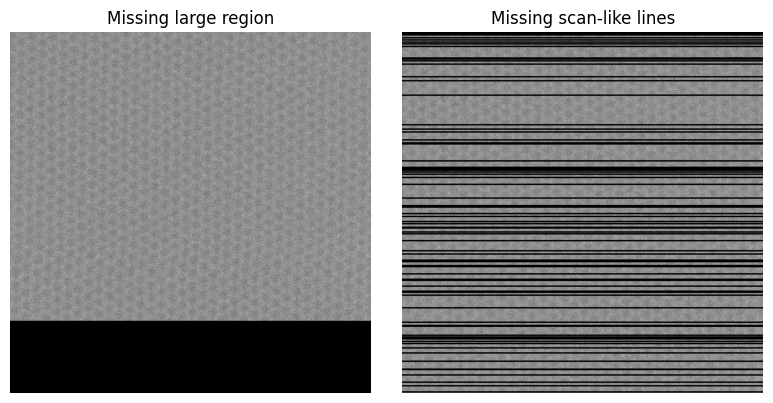

In [59]:
import matplotlib.pyplot as plt

# Generate corrupted images
img_large_region = mask_below_line(im0, frac=0.8) * im0
img_scan_lines = mask_lines(im0, seed=0) * im0

# Save individually as PNG
plt.imsave("Image0-missing_large_region.png", img_large_region, cmap="gray")
plt.imsave("Image0-missing_scan_lines.png", img_scan_lines, cmap="gray")

# Optional visualization
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img_large_region, cmap="gray")
ax[0].set_title("Missing large region")
ax[0].axis("off")

ax[1].imshow(img_scan_lines, cmap="gray")
ax[1].set_title("Missing scan-like lines")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### sub
Initiating Inpainting Analysis

I'm starting by analyzing the user's request, specifically the inpainting task for two microscopy images. The provided context indicates missing regions within image_2.png and image_3.png, and the user seeks to fill these regions. This phase involves understanding the images, context, and the nature of the missing data.

Defining Inpainting Requirements

I'm now focused on the inpainting requirements for the first image. The goal is to reconstruct the missing section, a horizontal black bar across the bottom. I'm noting the image is a grayscale texture, likely from SEM or AFM, characterized by a complex, granular pattern. I need to extrapolate this texture to fill the missing region, striving for visual consistency.

Formulating Composite Strategy

I'm now determining how to handle both images together. Since the user's primary request is about inpainting the two microscopy images, I will make an image which combines them. Image image_2.png is missing a solid bar at the bottom, and image_3.png is obscured by horizontal lines. I aim to create a comparison image of these two microscopy images.

Constructing Side-by-Side View

I'm now focused on constructing the side-by-side comparison image of the inpainted microscopy data. The prompt details a two-panel layout, left and right. The left panel will show the inpainted version of image_2.png, the one with the large missing region at the bottom. The right panel will show the inpainted version of image_3.png, obscured by horizontal lines. The aim is to make a seamless comparison for the user.

Constructing Comparison Image

I am now structuring the request for a combined image. I've broken down the user's intent into component parts. I will create a high-resolution, side-by-side scientific composite micrograph. The left panel will feature the inpainted version of image_2.png, titled "Inpainted Micrograph (Missing Large Region Restored)", and the right panel the inpainted image_3.png, titled "Inpainted Micrograph (Missing Scan Lines Restored)". The aim is to reconstruct each image's missing details and present a seamless comparison.

Formulating Overall Strategy

I'm now focused on the overall generation strategy. The recent work has been to combine two microscopy images, image_2.png and image_3.png, that need to be inpainted. My strategy involves analyzing each image individually, then creating a composite side-by-side view for comparison. I've formulated detailed plans for each, emphasizing a granular texture characteristic of SEM or AFM images. I've also constructed the prompt for this combined image, providing details such as image style, layout, content description, text, and title.

Refining Prompt for Image Generation

I'm working on refining the generation strategy for the combined image. The current focus is on a side-by-side composite that presents the inpainted microscopy images. I've broken down the prompt to ensure it specifies the granular texture required for each panel and the overall grayscale style. I'm taking care to ensure that the image details, such as the scale bars, titles, and overall layout, are clearly defined.

Refining Image Generation

I'm now implementing the generation strategy. I'm focusing on inpainting image_2.png and image_3.png and combining the results in a side-by-side comparison. The current step emphasizes reconstructing a granular texture for both images, making it consistent and seamlessly filling the missing regions. The process demands high resolution and attention to detail. I'm also ensuring the specified text elements and scale bars are included.

Analyzing Composite Results

I'm checking the results of the inpainting and composite generation process, confirming the side-by-side comparison of the two microscopy images, as requested. The left panel shows how the texture seamlessly replaces the black bar in image_2.png, retaining the microstructure. The right panel also seems to be progressing successfully.

Verifying Seamless Texture Generation

I've confirmed the seamless generation and comparison. The left panel shows the texture flawlessly replacing the black bar in the second image while keeping the microstructure. The right panel is successful, in-painting the entirety of the field, eliminating the black lines and reconstructing the granular texture, in the style of the first image. The titles, composition, and note about file names are all acceptable.

### returns a BS image - doesnt look like it looked at the image

### ChatGPT - 
ChatGPT Image May 8, 2026, 12_04_51 PM.png


Prompt - do inpainitng of these images :

context: they are microsocpy images - idea is that you loose information in scanning tue to hardware issue or you miss regions intentionaly to inpaint to save time - can we reconstruct it?

Activity
·
1m 3s

Thinking
Planning image inpainting task
The user wants the entire image inpainted, specifically the bottom black region to be replaced by extending the existing texture downward. I'll make sure the top portion, which already has texture, stays intact. The result should be a seamless grayscale microscopy-like image, with no panel splits. The aspect ratio is likely 1:1. Let’s go ahead and make the edit call.

Thought for 1m 3s
Done

### Gemini 

Gemini-1-inpainitng.png
Completely difernt - it did read the image but made entirely new one

### Clearly ChatGPT > Gemini?

Q. Try traditional inpainiting method?


In [24]:
from skimage.restoration import inpaint

def inpaint_skimage(im, mask):
    """
    mask : True = known, False = missing
    skimage expects: True = missing
    """
    # normalize
    im_min, im_max = im.min(), im.max()
    im_norm = (im - im_min) / (im_max - im_min)
    
    recon = inpaint.inpaint_biharmonic(im_norm, ~mask)   # note: flipped mask
    recon = recon * (im_max - im_min) + im_min   # denormalize
    return recon

In [25]:
def plot_method(im, mask, recon, std=None, title=''):
    """
    Reusable plot for any method.
    std optional — if None shows residual instead.
    """
    masked_im = im * mask

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(im,        cmap='gray'); axes[0].set_title('Original')
    axes[1].imshow(masked_im, cmap='gray'); axes[1].set_title('Masked')
    axes[2].imshow(recon,     cmap='gray'); axes[2].set_title(f'{title} Reconstruction')

    if std is not None:
        axes[3].imshow(std,              cmap='hot'); axes[3].set_title('Uncertainty (std)')
    else:
        axes[3].imshow(np.abs(im-recon), cmap='hot'); axes[3].set_title('|Residual|')

    for ax in axes: ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    


In [26]:
mask_im    = mask_below_line(im0)
ski_recon = inpaint_skimage(im0, mask_im)

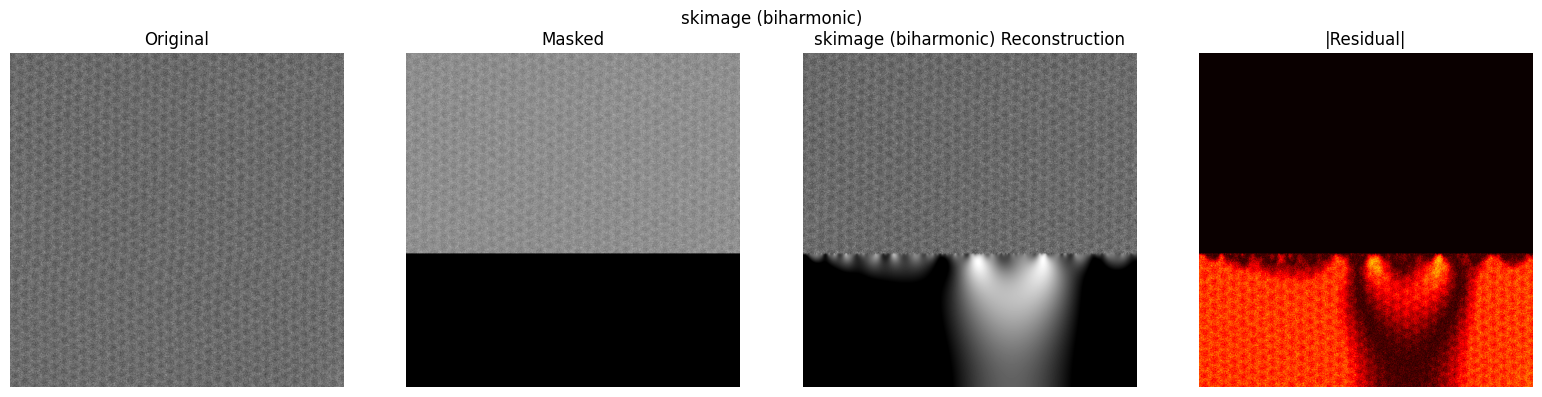

In [23]:
plot_method(im0, mask_im, ski_recon, std=None, title='skimage (biharmonic)')

In [30]:
from skimage.metrics import structural_similarity as ssim

## evaluate all three methods
def inpaint_score(gt, recon, missing):
    gt = gt.astype(float)
    recon = recon.astype(float)

    mse = np.mean((gt[missing] - recon[missing]) ** 2)
    mae = np.mean(np.abs(gt[missing] - recon[missing]))

    data_range = gt.max() - gt.min()
    psnr = 10 * np.log10((data_range**2) / (mse + 1e-12))

    ssim_full = ssim(gt, recon, data_range=data_range)

    return {
        "mse_missing": mse,      # lower better
        "mae_missing": mae,      # lower better
        "psnr_missing": psnr,    # higher better
        "ssim_full": ssim_full,  # higher better
    }
    
scores = inpaint_score(im0, ski_recon, ~mask_im )
print(scores)

{'mse_missing': 69059600.2724274, 'mae_missing': 7425.824236513555, 'psnr_missing': 8.864945456598106, 'ssim_full': 0.6278684543782029}


In [33]:
from PIL import Image


def read_png(path):
    """Read PNG as grayscale float image in [0, 1]."""
    img = Image.open(path).convert("L")
    return np.asarray(img).astype(np.float32) / 255.0

In [42]:
gpt_mask_below_predict = read_png("ChatGPT Image May 8, 2026, 12_04_51 PM.png")

from skimage.transform import resize

gpt_mask_below_predict_resized = resize(
    gpt_mask_below_predict,
    im0.shape,
    preserve_range=True,
    anti_aliasing=True
).astype(im0.dtype)

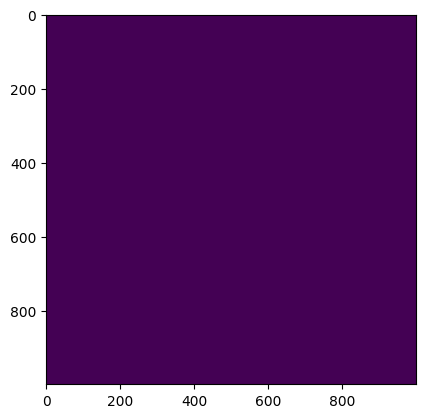

In [44]:
plt.imshow(gpt_mask_below_predict_resized )

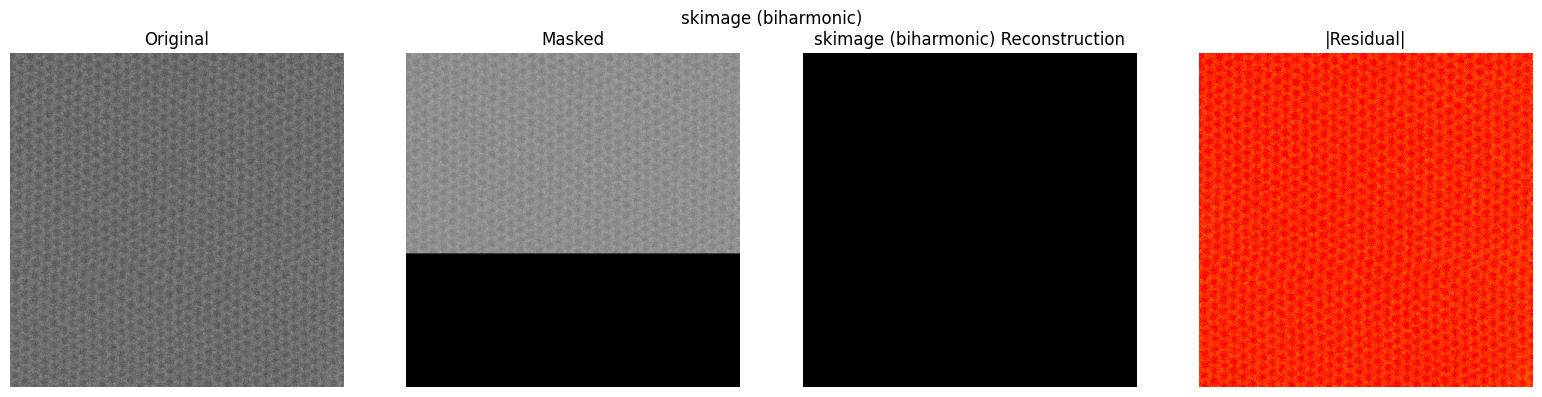

In [43]:
plot_method(im0, mask_im, gpt_mask_below_predict_resized, std=None, title='skimage (biharmonic)')